# ARIMA - SERIES TEMPORALES

### Ventas semanales de una cadena de supermercados

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [92]:
# ── Carga de datos ─────────────────────────────────────────────────────────────
data = pd.read_excel(
    r"arima.xlsx",
    parse_dates=["Fecha"],   # ← parsea la columna como datetime
    index_col="Fecha"        # ← la establece como índice
)

print(data.head())

                   Ventas
Fecha                    
2020-01-05  123514.188643
2020-01-12  123429.972871
2020-01-19  138711.065520
2020-01-26  131347.446215
2020-02-02  124776.510122


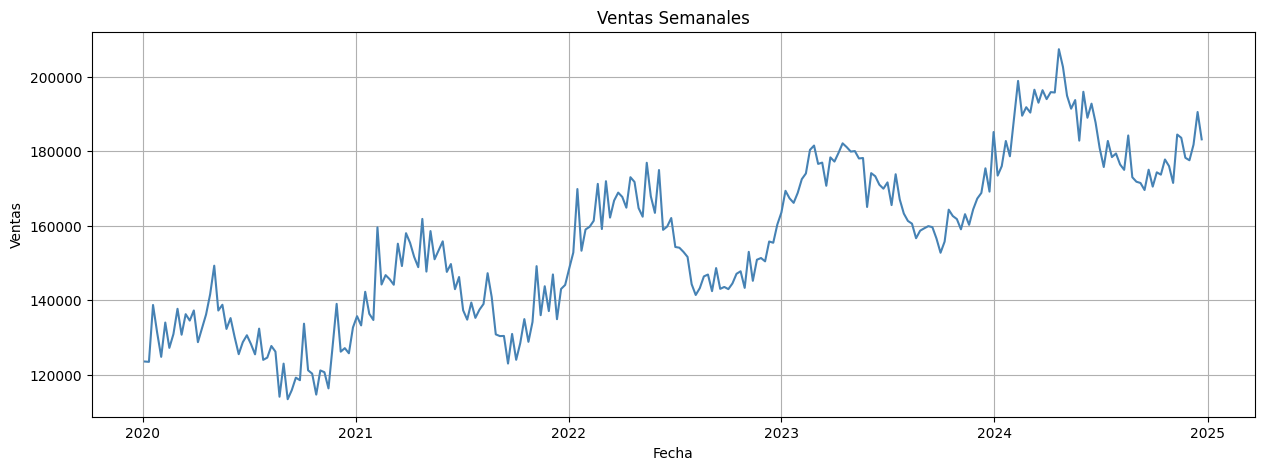

In [93]:
# ── Visualización de la serie temporal ────────────────────────────────────────
plt.figure(figsize=(15, 5))
plt.plot(data.index, data["Ventas"], color="steelblue")
plt.title("Ventas Semanales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid()
plt.show()

In [94]:
# ── Separación train / test ───────────────────────────────────────────────────
train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test  = data.iloc[train_size:]

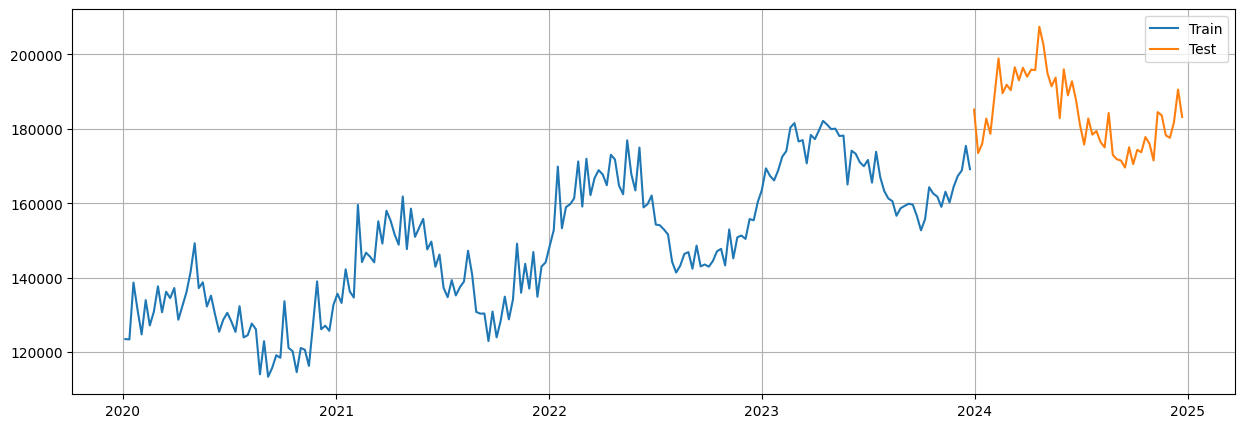

In [95]:
# ── Visualización train y test ────────────────────────────────────────────────
plt.figure(figsize=(15, 5))
plt.plot(train["Ventas"], label="Train")
plt.plot(test["Ventas"],  label="Test")
plt.legend()
plt.grid()
plt.show()

In [96]:
# ── Test de estacionariedad (Dickey-Fuller) ───────────────────────────────────
resultado = adfuller(train["Ventas"])

print("H0: la serie no es estacionaria")
print(f"ADF:     {resultado[0]:.4f}")
print(f"p-valor: {resultado[1]:.4f}")

if resultado[1] >= 0.05:
    print("→ La serie NO es estacionaria — necesario diferenciar (d ≥ 1)")
else:
    print("→ La serie ES estacionaria")

H0: la serie no es estacionaria
ADF:     -1.2482
p-valor: 0.6525
→ La serie NO es estacionaria — necesario diferenciar (d ≥ 1)


- ADF (estadístico) → Cuanto más negativo, más evidencia de estacionariedad.
- p-valor → La probabilidad de estar equivocado si rechazas H0.

In [97]:
# ── Diferenciación (d=1) y re-validación ─────────────────────────────────────
train_diff = train["Ventas"].diff().dropna()   # ← solo la Serie "Ventas"

resultado = adfuller(train_diff)
print(f"\nTras diferenciar:")
print(f"ADF:     {round(resultado[0], 4)}")
print(f"p-value: {round(resultado[1], 4)}")

if resultado[1] >= 0.05:
    print("→ La serie NO es estacionaria — considerar d=2")
else:
    print("→ La serie ES estacionaria")


Tras diferenciar:
ADF:     -14.8895
p-value: 0.0
→ La serie ES estacionaria


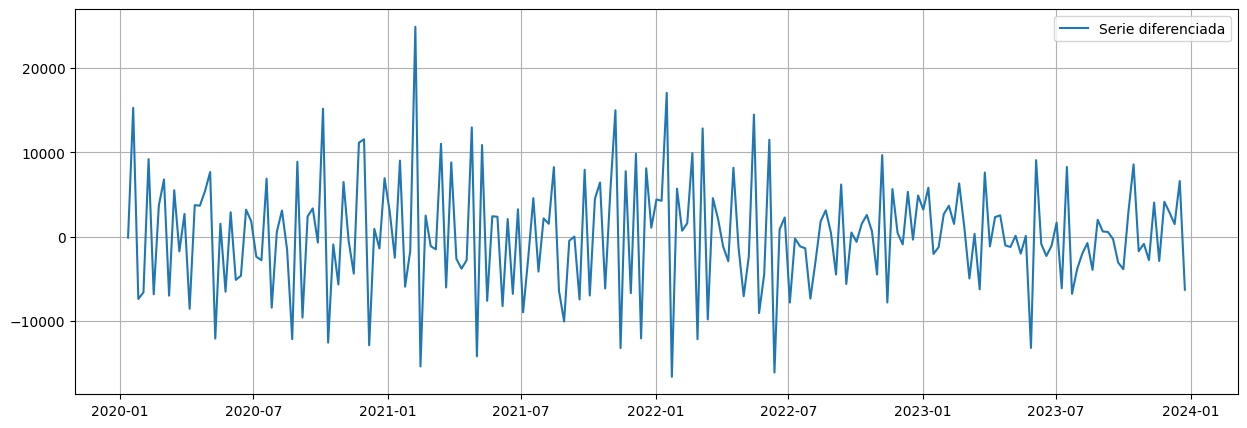

In [98]:
# ── Visualización de la serie diferenciada ───────────────────────────────────
plt.figure(figsize=(15, 5))                         # ← una sola figura
plt.plot(train_diff.index, train_diff, label="Serie diferenciada")
plt.legend()
plt.grid()
plt.show()


#plt.figure(figsize=(15,5))
#plt.plot(train_diff)
#plt.title("Serie diferenciada")
#plt.grid()
#plt.show()

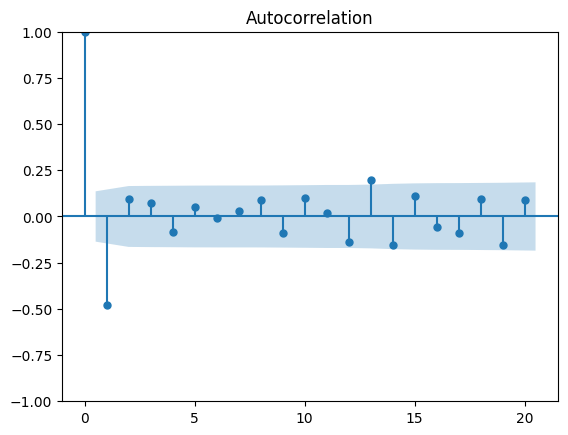

In [99]:
# Visualización de la función de autocorrelación ACF

# Detectamos el parametro Q

plot_acf(
    train_diff,
    lags=20
)
plt.show()

### La zona azul (banda de confianza)
- Barras DENTRO de la banda  →  correlación no significativa (ruido)
- Barras FUERA  de la banda  →  correlación significativa (señal real)

### Regla de lectura para q
- Solo el lag 1 sobresale, resto dentro | q = 1
- Lags 1 y 2 sobresalen, resto dentro | q = 2
- Decaimiento gradual exponencial | No es MA puro → mira PACF
- Todos dentro de la banda desde lag 0 | Serie ya es ruido blanco

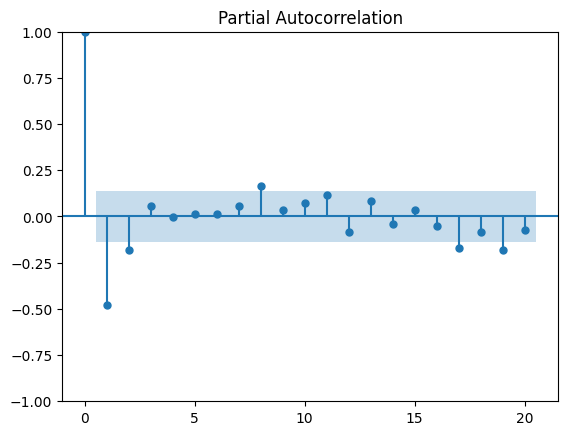

In [100]:
# Visualización de la función de autocorrelación parcial PACF

# Detectamos el parametro P


plot_pacf(
    train_diff,
    lags=20
)
plt.show()

#### La correlación directa entre la serie y su lag n, eliminando el efecto de los lags intermedios.
- Analogía: si las ventas de hoy dependen de las de hace 2 semanas, la PACF te dice si esa relación es real o simplemente consecuencia de que ambas dependen de las de hace 1 semana.

#### Regla de lectura para p
- Solo el lag 1 sobresale | p = 1

### Construir el modelo ARIMA



In [101]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [104]:
modelo = SARIMAX(
    train["Ventas"],
    order=(0,1,1),
    seasonal_order=(0,1,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo = modelo.fit()

c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [103]:
print(modelo.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             Ventas   No. Observations:                  208
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 52)   Log Likelihood               -1026.214
Date:                            Mon, 06 Jul 2026   AIC                           2060.427
Time:                                    16:50:53   BIC                           2070.888
Sample:                                01-05-2020   HQIC                          2064.662
                                     - 12-24-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6852      0.105     -6.535      0.000      -0.891      -0.480
ar.S.L52      -0.1482      0.222   

- AIC y BIC interesa que esto sea bajo

In [105]:
# Predicciones para el conjunto test

pred = modelo.get_forecast(
    steps=len(test)
)

pred_media = pred.predicted_mean
pred_ic = pred.conf_int()

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae=mean_absolute_error(
    test["Ventas"],
    pred_media
)

rmse = np.sqrt(
    mean_squared_error(
    test["Ventas"],
    pred_media
    )
)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 4035.12
RMSE: 4981.32


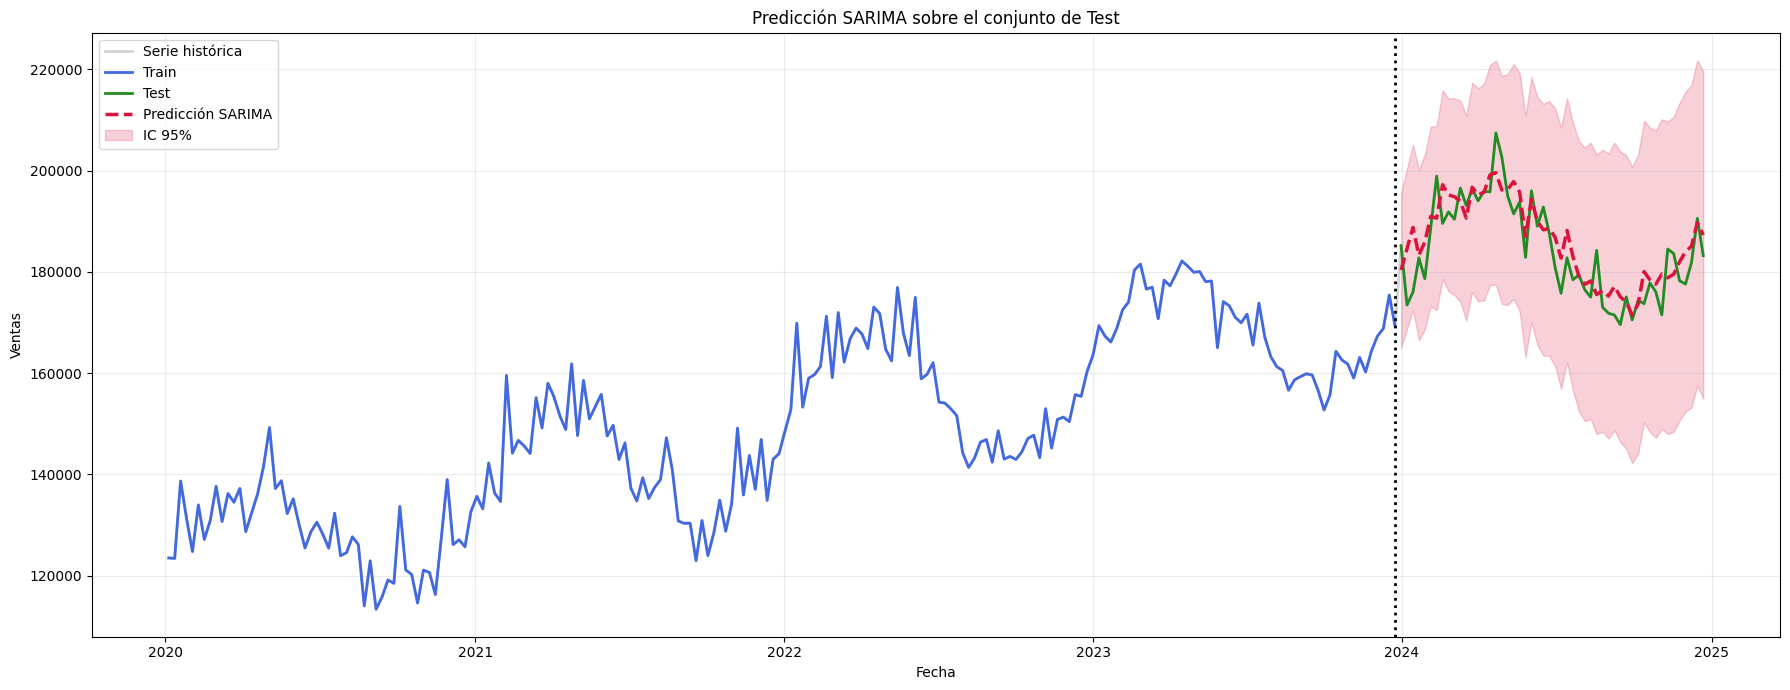

In [108]:
plt.figure(figsize=(18, 7))

# Histórico
plt.plot(
    data.index,
    data["Ventas"],
    color="lightgray",
    linewidth=2,
    label="Serie histórica"
)

# Train
plt.plot(
    train.index,
    train["Ventas"],
    color="royalblue",
    linewidth=2,
    label="Train"
)

# Test
plt.plot(
    test.index,
    test["Ventas"],
    color="forestgreen",
    linewidth=2,
    label="Test"
)

# Predicción
plt.plot(
    test.index,
    pred_media,
    color="crimson",
    linewidth=2.5,
    linestyle="--",
    label="Predicción SARIMA"
)

# Intervalo de confianza
plt.fill_between(
    test.index,
    pred_ic.iloc[:, 0],
    pred_ic.iloc[:, 1],
    color="crimson",
    alpha=0.20,
    label="IC 95%"
)

# Línea de separación
plt.axvline(
    train.index[-1],
    color="black",
    linestyle=":",
    linewidth=2
)

plt.title("Predicción SARIMA sobre el conjunto de Test")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [110]:
# Generación de predicciones

modelo_final = SARIMAX(
    data["Ventas"],
    order=(1,1,1),
    seasonal_order=(1,1,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = modelo_final.fit()

c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [121]:
# Horizonte temporal para las predicciones

horizonte = 20 # las semanas que queremos predecir
forecast = modelo_final.get_forecast(steps=horizonte)

In [122]:
pred_media = forecast.predicted_mean
pred_ic = forecast.conf_int()


In [124]:
future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(weeks=1),
    periods=horizonte,
    freq="W"
)

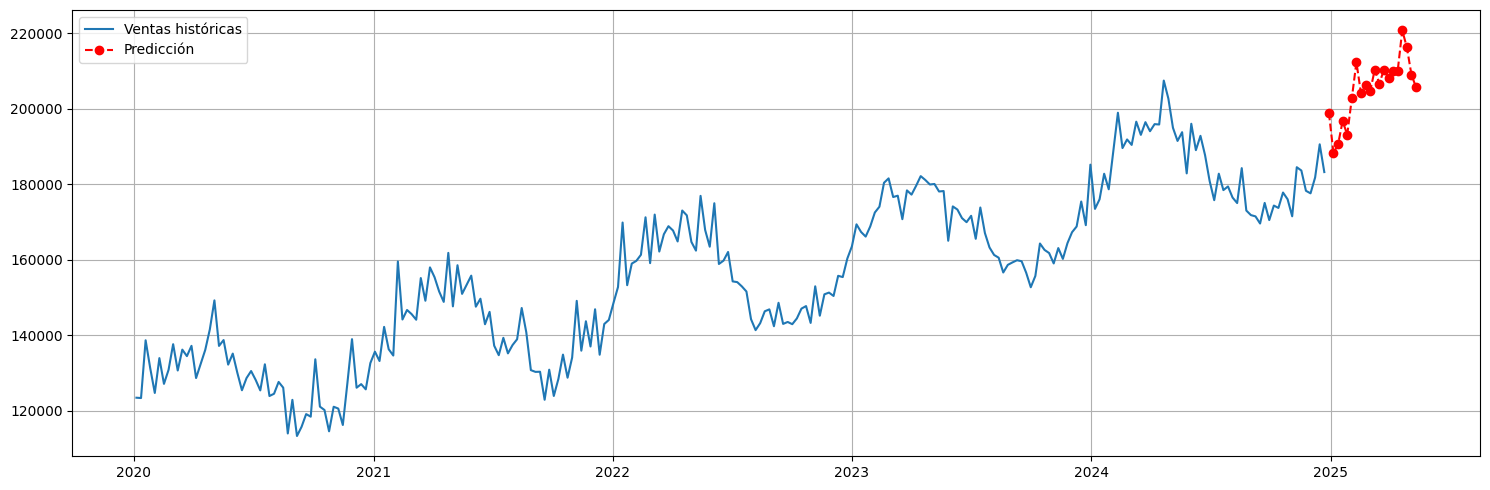

In [125]:
plt.figure(figsize=(15, 5))

plt.plot(
    data.index,
    data["Ventas"],
    label="Ventas históricas"
)

plt.plot(
    future_dates,
    pred_media.values,
    "ro--",
    label="Predicción"
)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()